In [1]:
# Install required libraries
!pip install scikit-learn pandas matplotlib numpy seaborn

In [2]:
# Import all necessary libraries
import numpy as np                                          
import pandas as pd                                         
import matplotlib.pyplot as plt                             
import seaborn as sns                                       
from sklearn.datasets import fetch_california_housing       
from sklearn.model_selection import train_test_split        
from sklearn.linear_model import LinearRegression           
from sklearn.tree import DecisionTreeRegressor              
from sklearn.ensemble import RandomForestRegressor          
from sklearn.metrics import mean_squared_error, r2_score    
from sklearn.preprocessing import StandardScaler           
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


# Load Dataset

In [4]:
# Load the California Housing dataset (built-in, no download needed)
housing = fetch_california_housing()

# Convert to pandas DataFrame
df = pd.DataFrame(housing.data, columns=housing.feature_names)

# Add target column - house prices (in $100,000s)
df['Price'] = housing.target

print("Dataset loaded successfully!")
print(f"\nShape: {df.shape[0]} rows x {df.shape[1]} columns")
print("\nFeature Names:")
for i, name in enumerate(housing.feature_names):
    print(f"  {i+1}. {name}")
print("\nFirst 5 rows:")
df.head()

Dataset loaded successfully!

Shape: 20640 rows x 9 columns

Feature Names:
  1. MedInc
  2. HouseAge
  3. AveRooms
  4. AveBedrms
  5. Population
  6. AveOccup
  7. Latitude
  8. Longitude

First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


#  Explore Data

In [5]:
# Check basic statistics of the dataset
print("Basic Statistics:")
print(df.describe())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check data types
print("\nData Types:")
print(df.dtypes)

Basic Statistics:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude         Price  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        0.6

# Visualize Data

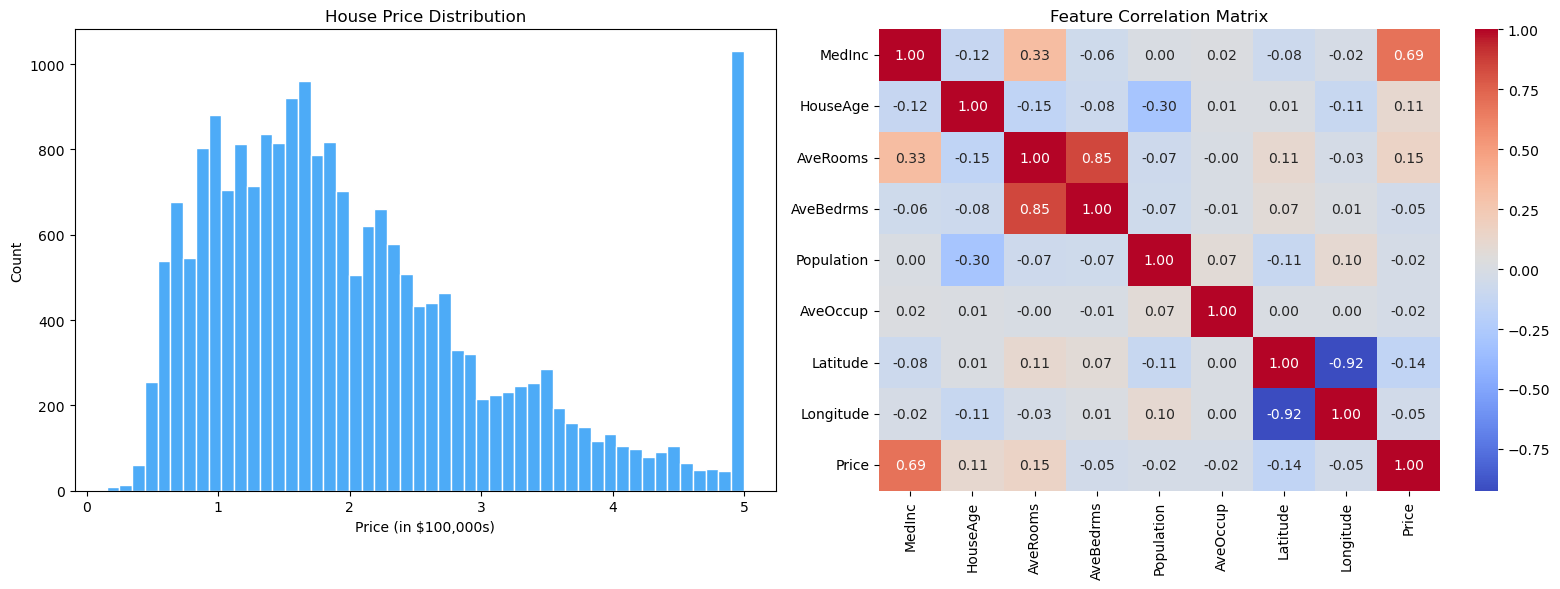

EDA chart saved as 'regression_eda.png'


In [6]:
# Visualize distribution and correlations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: House price distribution
axes[0].hist(df['Price'], bins=50, color='#4dabf7', edgecolor='white')
axes[0].set_title('House Price Distribution')
axes[0].set_xlabel('Price (in $100,000s)')
axes[0].set_ylabel('Count')

# Chart 2: Correlation heatmap between all features
correlation_matrix = df.corr()
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    ax=axes[1]
)
axes[1].set_title('Feature Correlation Matrix')

plt.tight_layout()
plt.savefig('regression_eda.png', dpi=150, bbox_inches='tight')
plt.show()

print("EDA chart saved as 'regression_eda.png'")

# Prepare Data

In [7]:
# Separate features (X) and target variable (y)
X = df.drop('Price', axis=1)    # All columns except Price
y = df['Price']                  # Target column - house price

# Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% data for testing
    random_state=42      # Fixed seed for reproducibility
)

print(f"Training set size  : {X_train.shape[0]} samples")
print(f"Testing set size   : {X_test.shape[0]} samples")

# Scale features using StandardScaler for better model performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # Fit on train, transform train
X_test_scaled = scaler.transform(X_test)          # Only transform test (no fit)

print("\nFeature scaling complete!")

Training set size  : 16512 samples
Testing set size   : 4128 samples

Feature scaling complete!


# Train Models

In [8]:
# Define all models to train and compare
models = {
    'Linear Regression'  : LinearRegression(),
    'Decision Tree'      : DecisionTreeRegressor(random_state=42),
    'Random Forest'      : RandomForestRegressor(n_estimators=100, random_state=42)
}

# Dictionary to store results
results = {}

print("Training models...\n")
print("-" * 55)

# Train and evaluate each model
for model_name, model in models.items():

    # Train the model on training data
    model.fit(X_train_scaled, y_train)

    # Make predictions on test set
    y_pred = model.predict(X_test_scaled)

    # Calculate evaluation metrics
    mse  = mean_squared_error(y_test, y_pred)   # Mean Squared Error
    rmse = np.sqrt(mse)                          # Root Mean Squared Error
    r2   = r2_score(y_test, y_pred)             # R-squared score (0 to 1)

    # Store results for comparison
    results[model_name] = {
        'MSE'         : round(mse, 4),
        'RMSE'        : round(rmse, 4),
        'R2 Score'    : round(r2, 4),
        'Predictions' : y_pred
    }

    print(f"{model_name}:")
    print(f"  MSE      : {mse:.4f}")
    print(f"  RMSE     : {rmse:.4f}")
    print(f"  R2 Score : {r2:.4f}")
    print("-" * 55)

Training models...

-------------------------------------------------------
Linear Regression:
  MSE      : 0.5559
  RMSE     : 0.7456
  R2 Score : 0.5758
-------------------------------------------------------
Decision Tree:
  MSE      : 0.4940
  RMSE     : 0.7028
  R2 Score : 0.6230
-------------------------------------------------------
Random Forest:
  MSE      : 0.2552
  RMSE     : 0.5051
  R2 Score : 0.8053
-------------------------------------------------------


# Compare Models

In [9]:
# Create a comparison table of all models
comparison_df = pd.DataFrame({
    'Model'    : list(results.keys()),
    'MSE'      : [results[m]['MSE'] for m in results],
    'RMSE'     : [results[m]['RMSE'] for m in results],
    'R2 Score' : [results[m]['R2 Score'] for m in results]
})

print("Model Comparison Table:")
print(comparison_df.to_string(index=False))

# Find the best model based on highest R2 score
best_model = comparison_df.loc[comparison_df['R2 Score'].idxmax(), 'Model']
best_r2    = comparison_df['R2 Score'].max()

print(f"\n🏆 Best Model  : {best_model}")
print(f"   Best R2 Score: {best_r2:.4f}")

Model Comparison Table:
            Model    MSE   RMSE  R2 Score
Linear Regression 0.5559 0.7456    0.5758
    Decision Tree 0.4940 0.7028    0.6230
    Random Forest 0.2552 0.5051    0.8053

🏆 Best Model  : Random Forest
   Best R2 Score: 0.8053


# Visualize Results

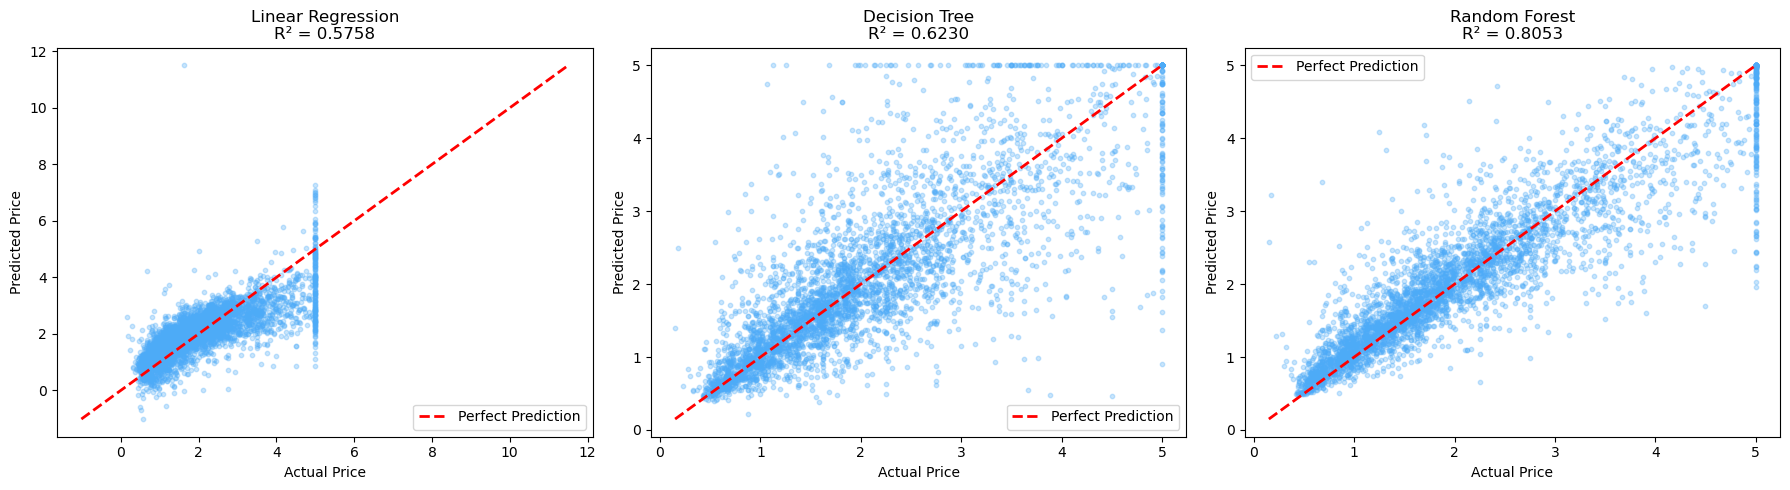

Results chart saved as 'regression_results.png'


In [10]:
# Plot Actual vs Predicted for all 3 models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (model_name, model_results) in enumerate(results.items()):

    # Scatter plot: Actual vs Predicted prices
    axes[idx].scatter(
        y_test,
        model_results['Predictions'],
        alpha=0.3,
        color='#4dabf7',
        s=10
    )

    # Perfect prediction line (red dashed)
    min_val = min(y_test.min(), model_results['Predictions'].min())
    max_val = max(y_test.max(), model_results['Predictions'].max())
    axes[idx].plot(
        [min_val, max_val],
        [min_val, max_val],
        'r--',
        linewidth=2,
        label='Perfect Prediction'
    )

    axes[idx].set_title(f'{model_name}\nR² = {model_results["R2 Score"]:.4f}')
    axes[idx].set_xlabel('Actual Price')
    axes[idx].set_ylabel('Predicted Price')
    axes[idx].legend()

plt.tight_layout()
plt.savefig('regression_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("Results chart saved as 'regression_results.png'")

# Feature Importance

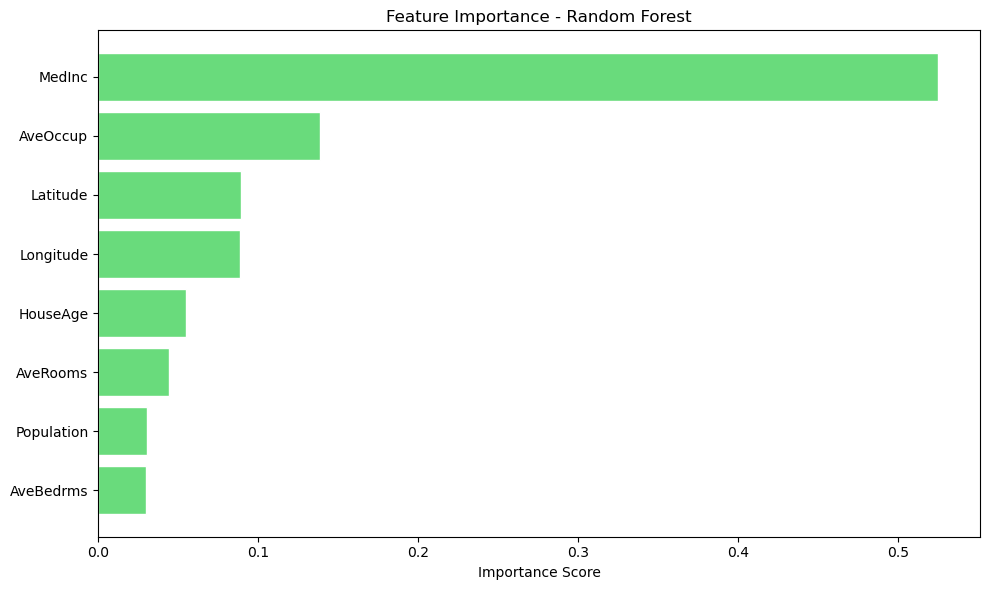

Feature Importance:
      Feature  Importance
0      MedInc    0.524871
5    AveOccup    0.138443
6    Latitude    0.088936
7   Longitude    0.088629
1    HouseAge    0.054593
2    AveRooms    0.044272
4  Population    0.030650
3   AveBedrms    0.029606

Feature importance chart saved!


In [11]:
# Get feature importance from Random Forest model
rf_model = models['Random Forest']

feature_importance = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

# Plot feature importance as horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance'],
    color='#69db7c',
    edgecolor='white'
)
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Feature Importance:")
print(feature_importance.sort_values('Importance', ascending=False))
print("\nFeature importance chart saved!")

# Summary

In [12]:
print("=" * 60)
print("  TASK 1 - PREDICTIVE MODELING (REGRESSION) - SUMMARY")
print("=" * 60)
print(f"\n  Dataset        : California Housing Dataset")
print(f"  Total Samples  : {df.shape[0]}")
print(f"  Features Used  : {X.shape[1]}")
print(f"  Train/Test     : 80% / 20%")
print(f"\n  Model Performance:")
print(comparison_df.to_string(index=False))
print(f"\n  Best Model     : {best_model}")
print(f"  Best R2 Score  : {best_r2:.4f}")
print(f"\n  Files Saved:")
print(f"    - regression_eda.png")
print(f"    - regression_results.png")
print(f"    - feature_importance.png")
print("=" * 60)

  TASK 1 - PREDICTIVE MODELING (REGRESSION) - SUMMARY

  Dataset        : California Housing Dataset
  Total Samples  : 20640
  Features Used  : 8
  Train/Test     : 80% / 20%

  Model Performance:
            Model    MSE   RMSE  R2 Score
Linear Regression 0.5559 0.7456    0.5758
    Decision Tree 0.4940 0.7028    0.6230
    Random Forest 0.2552 0.5051    0.8053

  Best Model     : Random Forest
  Best R2 Score  : 0.8053

  Files Saved:
    - regression_eda.png
    - regression_results.png
    - feature_importance.png
